In [ ]:
#import Libraries
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Load the Dataset
df = pd.read_csv("C:/Users/temp.admin/Documents/Stats AIDS/diabetes.csv")
df.head

<bound method NDFrame.head of      Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  Outcome  
0                       0.627   50 

In [ ]:
# checking for Null Values
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [ ]:
# checking for missing values
(df ==0).sum()

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

In [6]:
df_copy = df.copy()

In [7]:
cols = ['Glucose','BloodPressure','Insulin','BMI','SkinThickness']
df[cols] = df[cols].replace(0,np.nan)

In [8]:
# Fill missing values with median
for col in cols:
    median_value = df[col].median()
    df[col].fillna(median_value, inplace=True)
    print(f'{col} median used for imputation: {median_value}')

Glucose median used for imputation: 117.0
BloodPressure median used for imputation: 72.0
Insulin median used for imputation: 125.0
BMI median used for imputation: 32.3
SkinThickness median used for imputation: 29.0


In [9]:
df.isnull().sum()


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [ ]:
#Calculate Correaltion between the variables
df.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.128213,0.208615,0.081770,0.025047,0.021559,-0.033523,0.544341,0.221898
Glucose,0.128213,1.000000,0.218937,0.192615,0.419451,0.231049,0.137327,0.266909,0.492782
BloodPressure,0.208615,0.218937,1.000000,0.191892,0.045363,0.281257,-0.002378,0.324915,0.165723
SkinThickness,0.081770,0.192615,0.191892,1.000000,0.155610,0.543205,0.102188,0.126107,0.214873
Insulin,0.025047,0.419451,0.045363,0.155610,1.000000,0.180241,0.126503,0.097101,0.203790
BMI,0.021559,0.231049,0.281257,0.543205,0.180241,1.000000,0.153438,0.025597,0.312038
DiabetesPedigreeFunction,-0.033523,0.137327,-0.002378,0.102188,0.126503,0.153438,1.000000,0.033561,0.173844
Age,0.544341,0.266909,0.324915,0.126107,0.097101,0.025597,0.033561,1.000000,0.238356
Outcome,0.221898,0.492782,0.165723,0.214873,0.203790,0.312038,0.173844,0.238356,1.000000


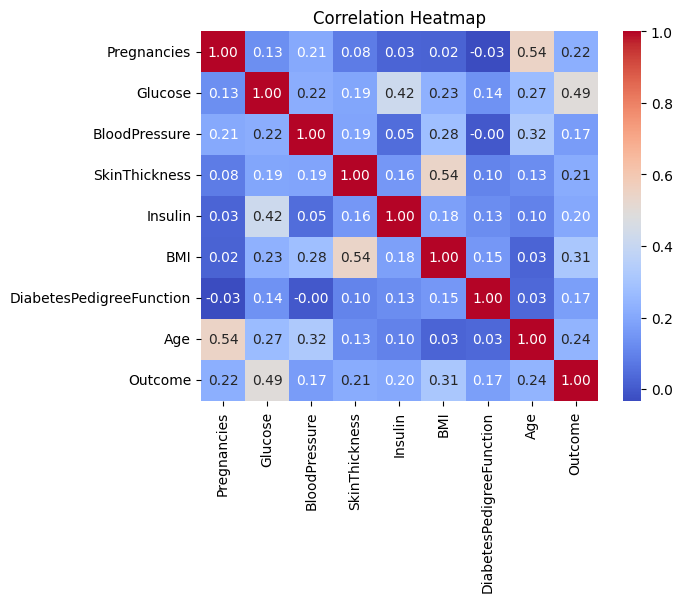

In [ ]:
# corelation through the heatmap
plt.Figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True,cmap='coolwarm',fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
#importing libraries for calculating Distance
from scipy.spatial.distance import euclidean,cityblock,cosine

In [13]:
x=df.iloc[0]
y=df.iloc[1]

eu_dist = euclidean(x,y)
man_dist = cityblock(x,y)
cos_dist = cosine(x,y)
print("Euclidean Distance " , eu_dist)
print("Manhanteen Distance ", man_dist)
print("Cosine Distance ", cos_dist)

Euclidean Distance  66.91095706982527
Manhanteen Distance  107.276
Cosine Distance  0.031632843799929145


In [ ]:

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_scaled = df.copy()
features = df.columns.drop("Outcome")
df_scaled[features] = scaler.fit_transform(df[features])
df_scaled.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,0.639947,0.866045,-0.031990,0.670643,-0.181541,0.166619,0.468492,1.425995,1
1,-0.844885,-1.205066,-0.528319,-0.012301,-0.181541,-0.852200,-0.365061,-0.190672,0
2,1.233880,2.016662,-0.693761,-0.012301,-0.181541,-1.332500,0.604397,-0.105584,1
3,-0.844885,-1.073567,-0.528319,-0.695245,-0.540642,-0.633881,-0.920763,-1.041549,0
4,-1.141852,0.504422,-2.679076,0.670643,0.316566,1.549303,5.484909,-0.020496,1


In [17]:
print("Before standardization:")
print(df[features].head())

print("\nAfter standardization:")
print(df_scaled[features].head())

Before standardization:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6    148.0           72.0           35.0    125.0  33.6   
1            1     85.0           66.0           29.0    125.0  26.6   
2            8    183.0           64.0           29.0    125.0  23.3   
3            1     89.0           66.0           23.0     94.0  28.1   
4            0    137.0           40.0           35.0    168.0  43.1   

   DiabetesPedigreeFunction  Age  
0                     0.627   50  
1                     0.351   31  
2                     0.672   32  
3                     0.167   21  
4                     2.288   33  

After standardization:
   Pregnancies   Glucose  BloodPressure  SkinThickness   Insulin       BMI  \
0     0.639947  0.866045      -0.031990       0.670643 -0.181541  0.166619   
1    -0.844885 -1.205066      -0.528319      -0.012301 -0.181541 -0.852200   
2     1.233880  2.016662      -0.693761      -0.012301 -0.181541 -1.332500 

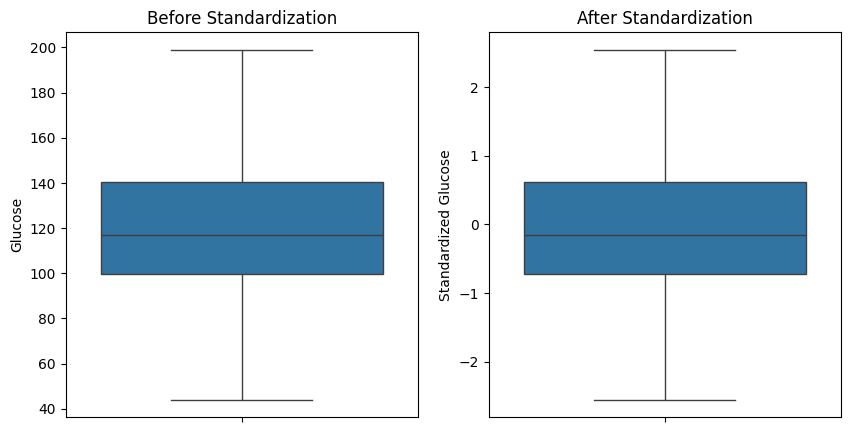

In [19]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
sns.boxplot(df["Glucose"])
plt.title("Before Standardization")
plt.ylabel("Glucose")

plt.subplot(1, 2, 2)
sns.boxplot(df_scaled["Glucose"])
plt.title("After Standardization")
plt.ylabel("Standardized Glucose")

plt.show()